In [57]:
import numpy as np
import pandas as pd

In [58]:
df = pd.read_csv('spam.csv', encoding = 'latin1')

In [59]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3143,ham,"Haha I heard that, text me when you're around",NaN,NaN,NaN
2801,ham,And smile for me right now as you go and the w...,NaN,NaN,NaN
3572,spam,You won't believe it but it's true. It's Incre...,NaN,NaN,NaN
5336,ham,Sounds better than my evening im just doing my...,NaN,NaN,NaN
1099,ham,Been up to ne thing interesting. Did you have ...,NaN,NaN,NaN


In [60]:
df.shape

(5572, 5)

In [61]:
# 1. Data Cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model Building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

## 1. Data Cleaning

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [63]:
# drop last 3 columns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],inplace=True)

In [64]:
df.sample(5)

,v1,v2
4032,ham,I am taking you for italian food. How about a ...
984,ham,Yo guess what I just dropped
1877,ham,This pen thing is beyond a joke. Wont a Biro d...
4374,spam,Ur TONEXS subscription has been renewed and yo...
5130,ham,Any way where are you and what doing.


In [65]:
# renaming the columns
df.rename(columns={'v1' : 'Target' , 'v2' : 'Text'},inplace=True)
df.sample(5)

,Target,Text
3586,ham,Our ride equally uneventful - not too many of ...
1367,ham,"I don't know, same thing that's wrong everyso ..."
4112,ham,Thought we could go out for dinner. I'll treat...
2957,spam,U have a secret admirer. REVEAL who thinks U R...
4761,ham,Me too! Have a lovely night xxx


In [66]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [67]:
df['Target'] = encoder.fit_transform(df['Target'])

In [68]:
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [69]:
# missing values ?
df.isnull().sum()

Target    0
Text      0
dtype: int64

In [70]:
# check for duplicate values
df.duplicated().sum()

np.int64(403)

In [71]:
# remove Duplicate Values
df = df.drop_duplicates(keep = 'first')

In [72]:
df.duplicated().sum()

np.int64(0)

In [73]:
df.shape

(5169, 2)

## 2. EDA

In [74]:
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [75]:
# here we will see how many ham/spam are there in our data
df['Target'].value_counts()

Target
0    4516
1     653
Name: count, dtype: int64

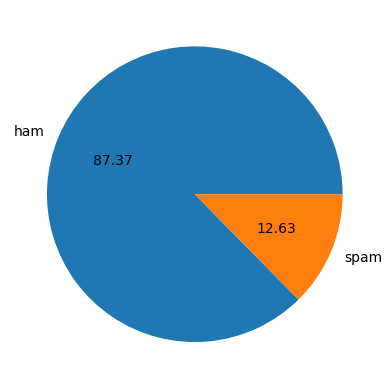

In [76]:
#here we will try to represent it with pie chart to see if our data is balanced or imbalanced
import matplotlib.pyplot as plt
plt.pie(df['Target'].value_counts(), labels=['ham','spam'], autopct="%0.2f")
plt.show()

In [77]:
#we can clearly see that our data is imbalanced

In [78]:
!pip install nltk

In [79]:
import nltk

In [80]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\chitr\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\chitr\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [81]:
#here we have importedthis library because we need3 more columns for no of characters, no of words, no of sentences

In [82]:
# for fetching no of characters
df['num_characters'] = df['Text'].apply(len)

In [83]:
df.head()

,Target,Text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [84]:
# for fetching number of words
df['num_words'] = df['Text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [85]:
df.head()

,Target,Text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [86]:
# for number of sentences
df['num_sentences'] = df['Text'].apply(lambda x:len(nltk.sent_tokenize(x))) 

In [87]:
df.head()

,Target,Text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [88]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [89]:
# we can analyse ham and spam seperately
# for ham messages
df[df['Target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [90]:
# for spam messages
df[df['Target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [91]:
import seaborn as sns

In [92]:
# now we will plot histogram for both ham/spam messages

<Axes: xlabel='num_characters', ylabel='Count'>

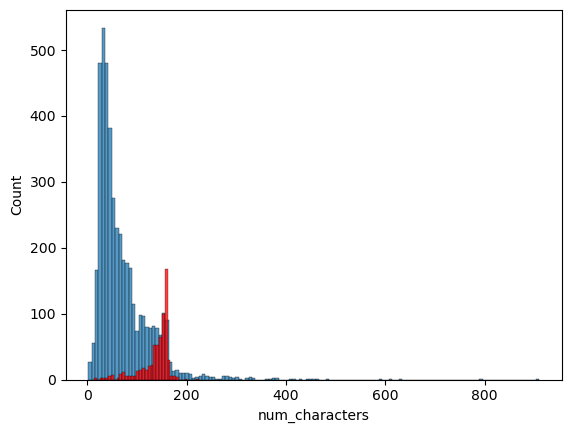

In [94]:
sns.histplot(df[df['Target'] == 0]['num_characters'])
sns.histplot(df[df['Target'] == 1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

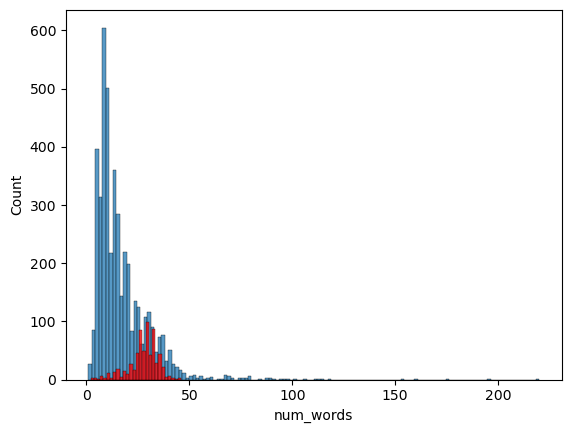

In [95]:
sns.histplot(df[df['Target'] == 0]['num_words'])
sns.histplot(df[df['Target'] == 1]['num_words'],color='red')

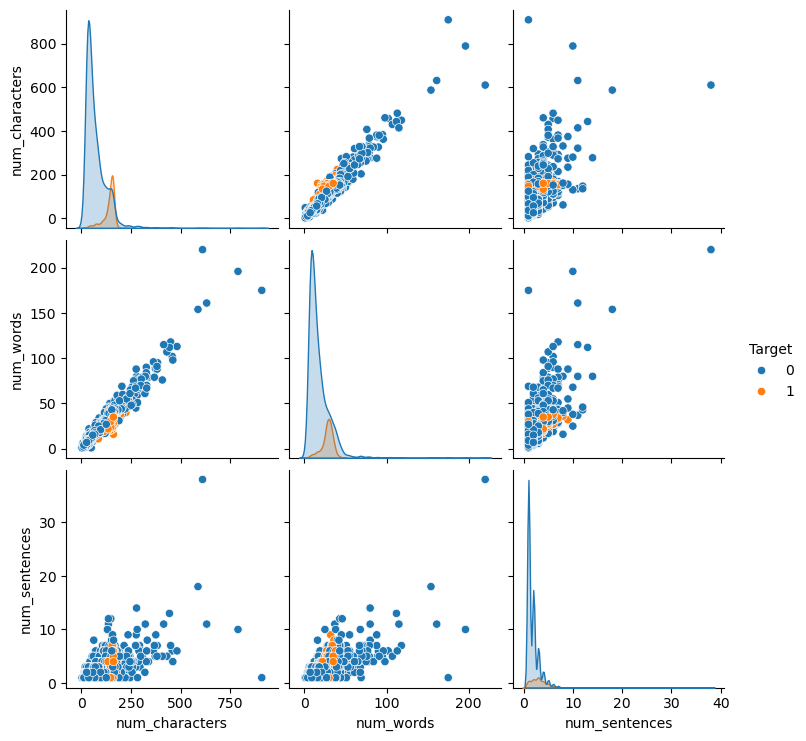

In [96]:
# for relation between num_characters and num_words
sns.pairplot(df, hue = 'Target')

<Axes: >

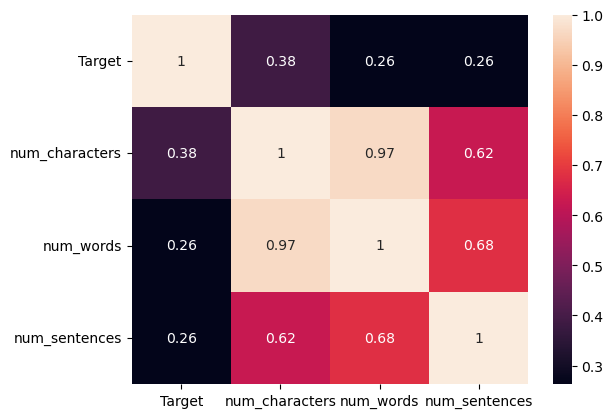

In [99]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

## 3. Data Preprocessing